In [32]:
from pathlib import Path
from timeit import default_timer as timer

import matplotlib.pyplot as plt
import numpy as np
from firedrake import *

In [33]:
OUTPUT_ROOT = Path("final/p1d1")
TEST_FUNCTION = "sin2"

CI_Z = 1.96
PLOT_TITLE = None

In [34]:
def _resolve_output_root(path: Path) -> Path:
    candidates = [path, Path("experimental_features") / path]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        f"Could not find {path!s}. Tried: "
        + ", ".join(str(candidate) for candidate in candidates)
    )


OUTPUT_ROOT = _resolve_output_root(OUTPUT_ROOT)
print(f"Output root: {OUTPUT_ROOT}")

Output root: /home/kam/PhD/dG-DK-paper/experiments/final/p1d1


In [35]:
TEST_FUNCTIONS = {
    "indicator_half": {
        "label": r"$1_{[\pi/2,3\pi/2]}$",
        "kind": "indicator",
        "interval": (np.pi / 2, 3 * np.pi / 2),
        "exact_particle_moment": 0.07245614571389715,
        "mfl_phi": 0.5082485133637601,
        "alignment_mod": 4,
        "notes": "Jump endpoints are mesh nodes iff nx is divisible by 4.",
    },
    "sin2": {
        "label": r"$\sin(2x)$",
        "kind": "fourier",
        "exact_particle_moment": 0.2753355179413845,
        "mfl_phi": 0.10804598838278799,
        "alignment_mod": None,
        "notes": "Single smooth mode 2.",
    },
}

print("Available test functions:")
for name, meta in TEST_FUNCTIONS.items():
    print(f"  {name:24s} exact={meta['exact_particle_moment']:.16g}  {meta['label']}")

if TEST_FUNCTION not in TEST_FUNCTIONS:
    raise KeyError(f"Unknown TEST_FUNCTION={TEST_FUNCTION!r}")

TEST_META = TEST_FUNCTIONS[TEST_FUNCTION]
EXACT_PARTICLE_MOMENT = TEST_META["exact_particle_moment"]

print(f"\nSelected: {TEST_FUNCTION}")
print(f"Label: {TEST_META['label']}")
print(f"Exact particle moment: {EXACT_PARTICLE_MOMENT:.17g}")
print(f"MFL pairing: {TEST_META['mfl_phi']:.17g}")
print(TEST_META.get("notes", ""))

Available test functions:
  indicator_half           exact=0.07245614571389715  $1_{[\pi/2,3\pi/2]}$
  sin2                     exact=0.2753355179413845  $\sin(2x)$

Selected: sin2
Label: $\sin(2x)$
Exact particle moment: 0.2753355179413845
MFL pairing: 0.10804598838278799
Single smooth mode 2.


In [36]:
def phi_expression(name, x):
    if name == "indicator_half":
        lo, hi = TEST_FUNCTIONS[name]["interval"]
        return conditional(And(x >= lo, x <= hi), 1.0, 0.0)
    if name == "sin2":
        return sin(2 * x)
    raise KeyError(name)

In [37]:
def parse_params_file(path: Path):
    params = {}
    for line in path.read_text().splitlines():
        if " = " not in line:
            continue
        key, value = line.split(" = ", 1)
        params[key.strip()] = value.strip()
    return params


def coerce_params(params):
    return {
        "experiment_id": params["experiment ID"],
        "nx": int(params["nx"]),
        "N": int(params["N"]),
        "total_runs": int(params["total runs"]),
        "eta": float(params["eta"]),
        "dt": float(params["dt"]),
        "T": float(params["T"]),
        "kappa": float(params["kappa"]),
        "degree": int(params["polynomial degree"]),
        "seed": int(params["SEED"]),
        "variant": params["variant"],
        "initial_condition_method": params["initial condition method"],
        "noise_gradient": params["noise gradient"],
        "procs": int(params["procs"]),
    }


experiment_rows = []
for folder in sorted(OUTPUT_ROOT.iterdir()):
    params_path = folder / "params.txt"
    if not folder.is_dir() or not params_path.exists():
        continue
    metadata = coerce_params(parse_params_file(params_path))
    metadata["folder"] = folder
    experiment_rows.append(metadata)

if not experiment_rows:
    raise FileNotFoundError(f"No experiment folders with params.txt found in {OUTPUT_ROOT}")

# If the same nx was run more than once, keep the lexicographically latest timestamped folder.
run_metadata = {}
for metadata in sorted(experiment_rows, key=lambda row: row["folder"].name):
    run_metadata[metadata["nx"]] = metadata

nxs = np.array(sorted(run_metadata), dtype=int)

for field in ["N", "total_runs", "degree", "T", "kappa", "noise_gradient"]:
    values = {run_metadata[int(nx)][field] for nx in nxs}
    if len(values) != 1:
        raise ValueError(f"Expected one {field} across this sweep, found {sorted(values)}")

N = run_metadata[int(nxs[0])]["N"]
total_runs = run_metadata[int(nxs[0])]["total_runs"]
degree = run_metadata[int(nxs[0])]["degree"]
T = run_metadata[int(nxs[0])]["T"]
kappa = run_metadata[int(nxs[0])]["kappa"]
noise_gradient = run_metadata[int(nxs[0])]["noise_gradient"]
procs = run_metadata[int(nxs[0])]["procs"]
SEED = run_metadata[int(nxs[0])]["seed"]

print(f"Using {len(nxs)} mesh sizes from {OUTPUT_ROOT.name}")
print(f"nxs: {nxs.tolist()}")
print(f"N={N}, M={total_runs}, degree={degree}, T={T}, kappa={kappa}, noise={noise_gradient}")
for nx in nxs:
    print(f"nx={int(nx):3d}: {run_metadata[int(nx)]['folder'].name}")

Using 6 mesh sizes from p1d1
nxs: [4, 6, 8, 10, 12, 14]
N=500000, M=60000, degree=1, T=0.1, kappa=1.0, noise=full
nx=  4: 20260722T171209399976_p1_nx004_N500000_dt0.001_T0.1_kappa1_eta10_equispaced_mfl-first_full_seed123_M60000_workers5
nx=  6: 20260722T173648885459_p1_nx006_N500000_dt0.001_T0.1_kappa1_eta10_equispaced_mfl-first_full_seed123_M60000_workers5
nx=  8: 20260722T180211654527_p1_nx008_N500000_dt0.001_T0.1_kappa1_eta10_equispaced_mfl-first_full_seed123_M60000_workers5
nx= 10: 20260722T182734922968_p1_nx010_N500000_dt0.001_T0.1_kappa1_eta10_equispaced_mfl-first_full_seed123_M60000_workers5
nx= 12: 20260722T185257292948_p1_nx012_N500000_dt0.001_T0.1_kappa1_eta10_equispaced_mfl-first_full_seed123_M60000_workers5
nx= 14: 20260722T191859771493_p1_nx014_N500000_dt0.001_T0.1_kappa1_eta10_equispaced_mfl-first_full_seed123_M60000_workers5


In [38]:
def first_matching_file(folder: Path, pattern: str):
    matches = sorted(folder.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No files matching {pattern!r} in {folder}")
    return matches[0]


def compute_dk_samples_for_nx(nx: int):
    metadata = run_metadata[nx]
    folder = metadata["folder"]
    mesh = PeriodicIntervalMesh(ncells=nx, length=2 * np.pi)
    DG = FunctionSpace(mesh, "DG", degree)
    v = TestFunction(DG)
    x, = SpatialCoordinate(mesh)

    phi_interp = Function(DG).interpolate(phi_expression(TEST_FUNCTION, x))
    weights = assemble(phi_interp * v * dx).dat.data_ro.copy()

    mfl_path = first_matching_file(
        folder,
        f"worker*_mfl_p{degree}_nx{nx:03d}_noise-{noise_gradient}.npy",
    )
    mfl = np.load(mfl_path)

    rho_paths = sorted(folder.glob(f"worker*_dk_p{degree}_nx{nx:03d}_noise-{noise_gradient}.npz"))
    if not rho_paths:
        raise FileNotFoundError(f"No DK worker files found in {folder}")

    samples = []
    for rho_path in rho_paths:
        with np.load(rho_path) as rhos:
            keys = [key for key in rhos.files if key != "allow_pickle"]
            for key in tqdm(keys, desc=f"nx={nx} {rho_path.name}", leave=False):
                rho = rhos[key]
                l2_inner = np.dot(mfl - rho, weights)
                samples.append((np.sqrt(N) * l2_inner) ** 2)

    return np.asarray(samples, dtype=float)


def compute_all_dk_samples():
    out = {}
    for nx in nxs:
        nx = int(nx)
        t0 = timer()
        out[nx] = compute_dk_samples_for_nx(nx)
        t1 = timer()
        print(f"nx={nx:3d}: loaded {out[nx].size} samples in {t1 - t0:.2f}s")
    return out


psi_l2_inner_dict_interp = compute_all_dk_samples()

nx=  4: loaded 60000 samples in 20.36s


nx=  6: loaded 60000 samples in 17.27s


nx=  8: loaded 60000 samples in 18.04s


nx= 10: loaded 60000 samples in 17.18s


nx= 12: loaded 60000 samples in 17.08s


nx= 14: loaded 60000 samples in 17.21s


produce error table

In [39]:
rows = []
for nx in nxs:
    nx = int(nx)
    dk_samples = np.asarray(psi_l2_inner_dict_interp[nx], dtype=float)
    dk_mean = float(np.mean(dk_samples))
    dk_std = float(np.std(dk_samples, ddof=1))
    dk_se = dk_std / np.sqrt(dk_samples.size)
    signed_difference = dk_mean - EXACT_PARTICLE_MOMENT
    weak_error = abs(signed_difference)
    ci95_halfwidth = CI_Z * dk_se

    if signed_difference - ci95_halfwidth <= 0.0 <= signed_difference + ci95_halfwidth:
        abs_ci95_low = 0.0
        abs_ci95_high = max(abs(signed_difference - ci95_halfwidth), abs(signed_difference + ci95_halfwidth))
    elif signed_difference > 0:
        abs_ci95_low = signed_difference - ci95_halfwidth
        abs_ci95_high = signed_difference + ci95_halfwidth
    else:
        abs_ci95_low = -(signed_difference + ci95_halfwidth)
        abs_ci95_high = -(signed_difference - ci95_halfwidth)

    row = {
        "nx": nx,
        "h": float(2 * np.pi / nx),
        "dk_samples": int(dk_samples.size),
        "dk_mean": dk_mean,
        "exact_particle_moment": EXACT_PARTICLE_MOMENT,
        "signed_difference": signed_difference,
        "weak_error_abs": weak_error,
        "dk_std": dk_std,
        "dk_se": dk_se,
        "ci95_halfwidth": ci95_halfwidth,
        "signed_ci95_low": signed_difference - ci95_halfwidth,
        "signed_ci95_high": signed_difference + ci95_halfwidth,
        "abs_ci95_low": max(abs_ci95_low, 0.0),
        "abs_ci95_high": max(abs_ci95_high, 0.0),
        "signed_ci95_contains_zero": bool(signed_difference - ci95_halfwidth <= 0.0 <= signed_difference + ci95_halfwidth),
        "relative_ci95_halfwidth": np.inf if weak_error == 0.0 else ci95_halfwidth / weak_error,
    }
    alignment_mod = TEST_META.get("alignment_mod")
    row["aligned"] = None if alignment_mod is None else bool(nx % alignment_mod == 0)
    rows.append(row)

for i, row in enumerate(rows):
    if i == 0:
        row["eoc"] = np.nan
        continue

    error_prev = rows[i - 1]["weak_error_abs"]
    error_curr = row["weak_error_abs"]
    h_prev = rows[i - 1]["h"]
    h_curr = row["h"]

    if error_prev > 0.0 and error_curr > 0.0 and h_prev != h_curr:
        row["eoc"] = np.log(error_curr / error_prev) / np.log(h_curr / h_prev)
    else:
        row["eoc"] = np.nan

for row in rows:
    aligned_text = ""
    if row["aligned"] is not None:
        aligned_text = f"  aligned={row['aligned']}"

    eoc_text = "   ---" if np.isnan(row["eoc"]) else f"{row['eoc']:6.2f}"
    print(
        f"nx={row['nx']:3d}  weak={row['weak_error_abs']:.4e}  "
        f"dk_se={row['dk_se']:.2e}  "
        f"EOC={eoc_text}  "
    )

nx=  4  weak=2.7534e-01  dk_se=1.52e-29  EOC=   ---  
nx=  6  weak=1.1503e-02  dk_se=1.66e-03  EOC=  7.83  
nx=  8  weak=2.5081e-02  dk_se=1.74e-03  EOC= -2.71  
nx= 10  weak=1.7043e-02  dk_se=1.68e-03  EOC=  1.73  
nx= 12  weak=1.1863e-02  dk_se=1.65e-03  EOC=  1.99  
nx= 14  weak=8.8671e-03  dk_se=1.64e-03  EOC=  1.89  


produce associated convergence plot

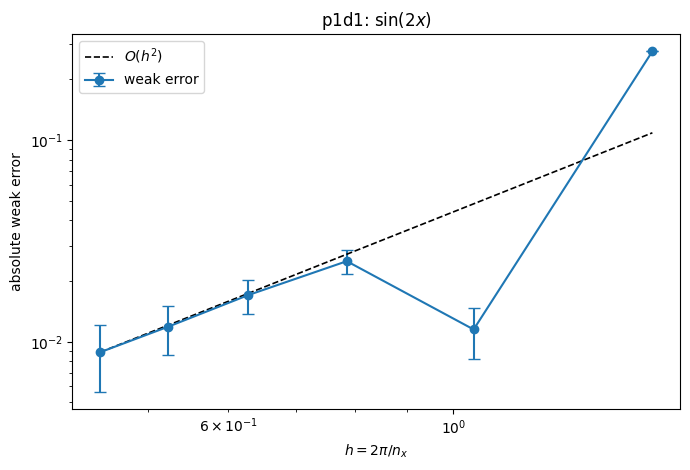

In [40]:
def _reference_line(hs, ys, slope, anchor_index=0):
    hs = np.asarray(hs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    positive = np.flatnonzero(ys > 0)
    if positive.size == 0:
        return None
    anchor = positive[min(anchor_index, positive.size - 1)]
    constant = ys[anchor] / hs[anchor] ** slope
    return constant * hs ** slope


hs = np.asarray([row["h"] for row in rows], dtype=float)
y = np.asarray([row["weak_error_abs"] for row in rows], dtype=float)
se = np.asarray([row["dk_se"] for row in rows], dtype=float)
abs_low = np.asarray([row["abs_ci95_low"] for row in rows], dtype=float)
abs_high = np.asarray([row["abs_ci95_high"] for row in rows], dtype=float)

# Sort by h for plotting left-to-right on log axes.
order = np.argsort(hs)
hs_p = hs[order]
y_p = y[order]
se_p = se[order]
abs_low_p = abs_low[order]
abs_high_p = abs_high[order]
rows_p = [rows[i] for i in order]

lower_err = np.maximum(y_p - abs_low_p, 0.0)
upper_err = np.maximum(abs_high_p - y_p, 0.0)
# Avoid trying to draw lower error bars through zero on a log axis.
y_floor = max(np.min(y_p[y_p > 0]) * 0.05, 1e-16)
lower_err = np.minimum(lower_err, np.maximum(y_p - y_floor, 0.0))

fig, ax = plt.subplots(figsize=(7.0, 4.8))

alignment_mod = TEST_META.get("alignment_mod")
if alignment_mod is None:
    ax.errorbar(hs_p, y_p, yerr=np.vstack([lower_err, upper_err]), marker="o", capsize=4, label="weak error")
else:
    aligned = np.asarray([row["aligned"] for row in rows_p], dtype=bool)
    for mask, label, marker in [(aligned, "aligned", "o"), (~aligned, "misaligned", "s")]:
        if not np.any(mask):
            continue
        ax.errorbar(
            hs_p[mask],
            y_p[mask],
            yerr=np.vstack([lower_err[mask], upper_err[mask]]),
            marker=marker,
            capsize=4,
            linestyle="-",
            label=label,
        )

#ref = _reference_line(hs_p, y_p, REFERENCE_SLOPE)
ref = _reference_line(hs_p, y_p, 2)
if ref is not None:
    ax.plot(hs_p, ref, linestyle="--", color="black", linewidth=1.2, label=rf"$O(h^{{{2:g}}})$")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$h=2\pi/n_x$")
ax.set_ylabel("absolute weak error")
ax.set_title(PLOT_TITLE or f"{OUTPUT_ROOT.name}: {TEST_META['label']}")
ax.legend()
fig.tight_layout()
plt.show()